# Visual Exploration: Overall group

1. Overall response distribution

2. Counts and proportions by condition
    - Goal Type
    - Agency
    - Goal Type x Agency

Import libraries

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

Read data

In [36]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

Clean data

In [37]:
responses["Response"] = responses["Response"].str.strip()

responses = responses.rename(
    columns={"Partcipant_ID": "Participant_ID"}
)

## 1. Overall response distribution

**Overall response distribution plot**

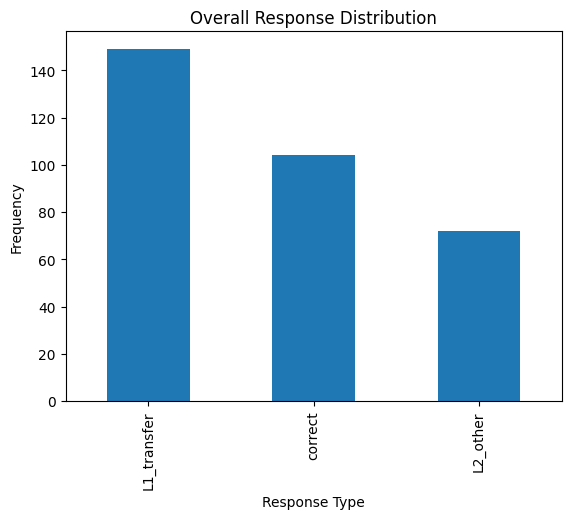

In [38]:
responses["Response"].value_counts().plot(kind="bar")

plt.title("Overall Response Distribution")
plt.xlabel("Response Type")
plt.ylabel("Frequency")

plt.show()

What we can immediately see is that transfer dominates the response landscape, which entails that the learner system might not be able to sustain counterfactual representation under high processing contstraints. Thus, transfer could end up being the closest representational solution. 

**Overall response counts and proportions plot**

In [39]:
pd.crosstab(
    responses["Goal_Type"],
    responses["Response"],
)

Response,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,45,22,42
goal_non_frequent,55,19,34
no_goal,49,31,28


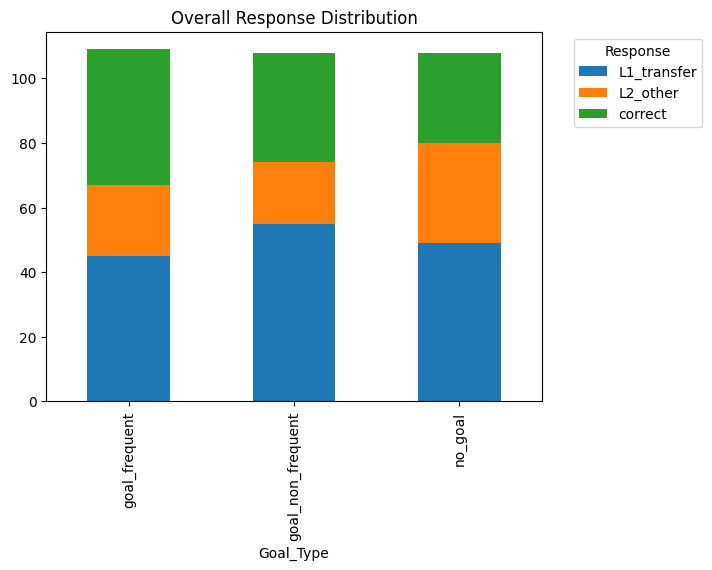

In [40]:
pd.crosstab(
    responses["Goal_Type"],
    responses["Response"]
).plot(kind="bar", stacked=True)

plt.title("Overall Response Distribution")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 2. Counts and Proportion by condition

*Responses by Goal Type:

- Counts
- Proportions 
- Proportions plot*

In [41]:
goal_response_counts = pd.crosstab(
    responses["Goal_Type"],
    responses["Response"],
    dropna=False,
    margins= True
)

goal_response_counts

Response,L1_transfer,L2_other,correct,NaN,All
Goal_Type,,,,,
goal_frequent,45,22,42,3,112
goal_non_frequent,55,19,34,4,112
no_goal,49,31,28,4,112
All,149,72,104,11,336


In [42]:
goal_response_props = pd.crosstab(
    responses["Goal_Type"],
    responses["Response"],
    normalize="index",
    dropna=False
)

goal_response_props

Response,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,0.401786,0.196429,0.375000,0.026786
goal_non_frequent,0.491071,0.169643,0.303571,0.035714
no_goal,0.437500,0.276786,0.250000,0.035714


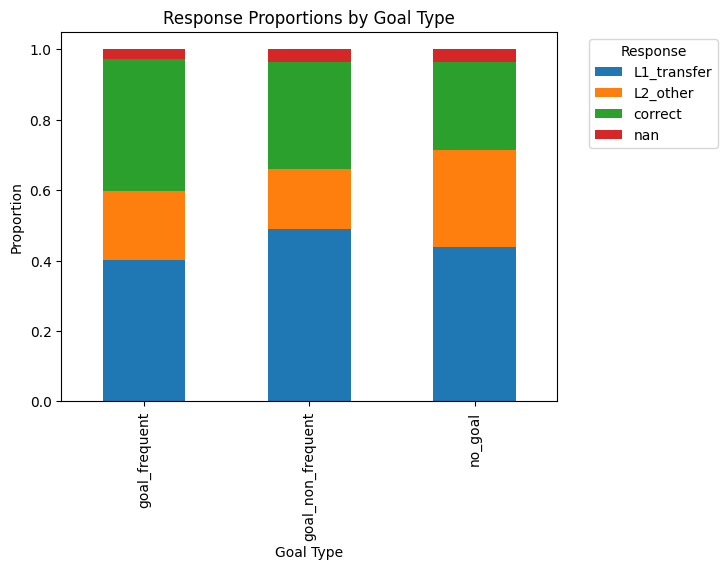

In [43]:
goal_response_props.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Goal Type")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

Cautiously, as this is just an initial exploration, what we can see is that:

- goal_frequent looks like the most supportive condition for succesful, or grammatically correct, resolution. 

- no_goal seems to produce fewer correct responses but fall into alternative L2 approximations.

- goal_non_frequent seems to be the most supportive condition for resolution by means of transfer. 

- Missing values are slightly lower in goal-frequent

**Responses by Agent:

- Counts
- Proportions 
- Proportions plot**

In [44]:
agent_response_counts = pd.crosstab(
    responses["Agent"],
    responses["Response"],
    dropna=False,
    margins= True
)

agent_response_counts

Response,L1_transfer,L2_other,correct,NaN,All
Agent,,,,,
0,80,52,57,9,198
1,69,20,47,2,138
All,149,72,104,11,336


In [45]:
agent_response_props = pd.crosstab(
    responses["Agent"],
    responses["Response"],
    normalize="index",
    dropna=False
)

agent_response_props

Response,L1_transfer,L2_other,correct,NaN
Agent,,,,
0,0.40404,0.262626,0.287879,0.045455
1,0.50000,0.144928,0.340580,0.014493


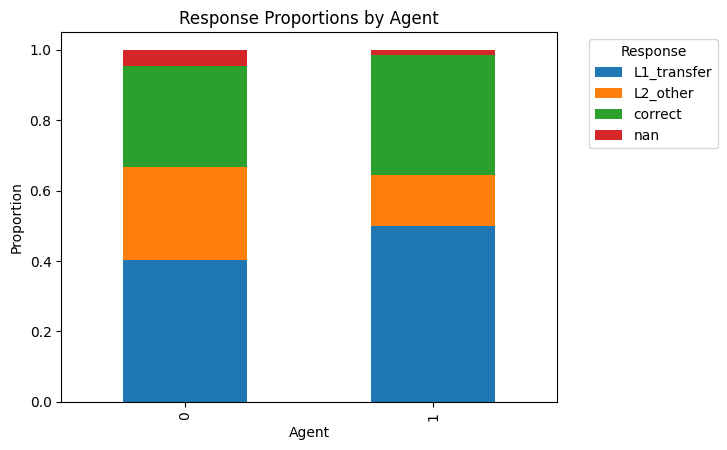

In [46]:
agent_response_props.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Agent")
plt.xlabel("Agent")
plt.ylabel("Proportion")

plt.legend(
    title="Response",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

Initially, it looks like agency seems to assist in how learners solve the problem:

- When there is an explicit Agent (Agent = 1) in the antecedent: 

    - learners may be commiting more strongly to a representation, either by means of a correct or a transfer response. 
    - by extension, theres is less room for L2 alternatives
    - there are fewer nan values

- When there isn't an explicit Agent (Agent = 0) in the antecedent: 

    - learners might be less structurally committed allowing for more L2 interpretations and fewer resolution responses either by means of a correct or a transfer response.
    - intestingly, 9 of the 11 nan values fall her. From this, and even though it is very early to say, even though the null proportion is overall very small, it is seems to be systematically patterned. 


*Responses by Goal Type and Agent:

- Counts
- Proportions 
- Proportions plot*

In [47]:
goal_agent_response_counts = pd.crosstab(
    [responses["Goal_Type"], responses["Agent"]],
    responses["Response"],
    dropna=False,
    margins= True
)

goal_agent_response_counts

Response                 L1_transfer  L2_other  correct  NaN  All
Goal_Type         Agent                                          
goal_frequent     0               23        18       22    3   66
                  1               22         4       20    0   46
goal_non_frequent 0               30        13       20    3   66
                  1               25         6       14    1   46
no_goal           0               27        21       15    3   66
                  1               22        10       13    1   46
All                              149        72      104   11  336

In [48]:
goal_agent_response_props = pd.crosstab(
    [responses["Goal_Type"], responses["Agent"]],
    responses["Response"],
    normalize="index",
    dropna=False
)

goal_agent_response_props

Response                 L1_transfer  L2_other   correct       NaN
Goal_Type         Agent                                           
goal_frequent     0         0.348485  0.272727  0.333333  0.045455
                  1         0.478261  0.086957  0.434783  0.000000
goal_non_frequent 0         0.454545  0.196970  0.303030  0.045455
                  1         0.543478  0.130435  0.304348  0.021739
no_goal           0         0.409091  0.318182  0.227273  0.045455
                  1         0.478261  0.217391  0.282609  0.021739

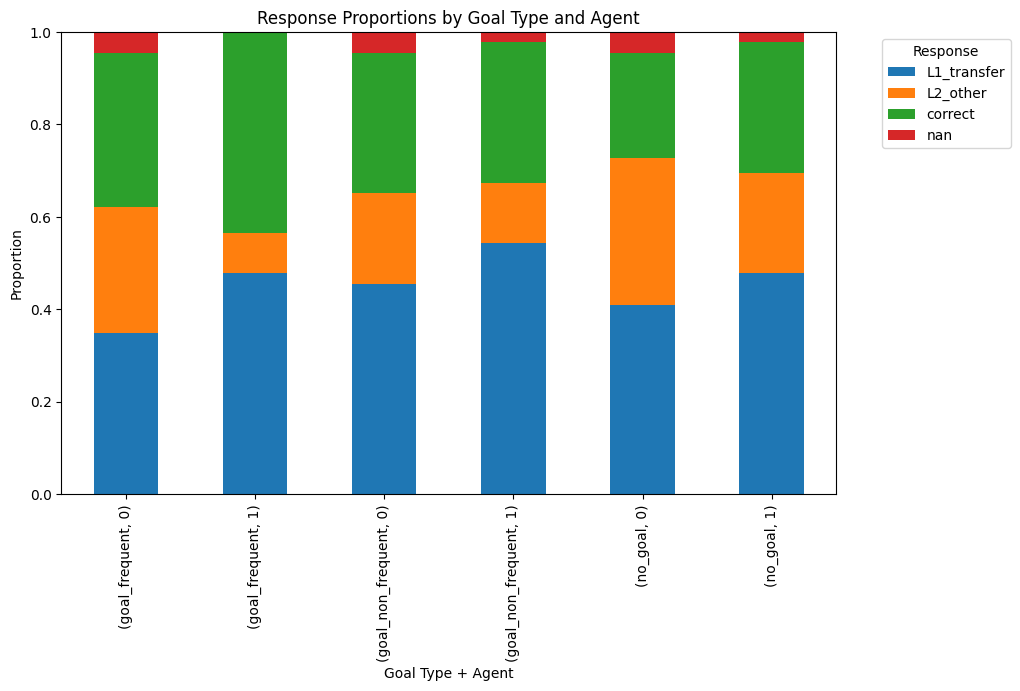

In [49]:
goal_agent_response_props.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Response Proportions by Goal Type and Agent")
plt.xlabel("Goal Type + Agent")
plt.ylabel("Proportion")

plt.legend(
    title="Response",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

Again, cautiously, as this is a very early visual exploration:

 - goal_frequent and agent = 1 carries the highest proportion of correct responses (0.435) among conditions; however, the proportion of transfer resolution is, in fact, pretty even but slightly higher (0.478) while leaving the smallest room for L2 alternatives. This favors the idea of a conceptual facilitation. 
 
 - Having the tranfer resolution highest proportion (0.543) when goal_non_frequent and agent = 1 brings the idea of maximal representational pressure when there is an explicit agent and thus, explicit accountability and/ or explicit liability. This could be supported by the fact that that having an explicit agent or not does not make a difference when it comes to rseolving correctly: the L2 reponses proportion when agent = 0 is not going to correct resolution when agent = 1 but to resolving by transfer. 
 
 - no_goal shows the highest proportion of L2_other responses when agent = 0; when agent = 1, facilitation also takes place favoring both correct and transfer resolution, but still keeps the highest proportion of L2_other responses when agent = 1.

 - back to the null distribution, it is interesting to see that participants decided not to answer and move on to the next question more often when agent = 0, and no missing values when goal_frequent and agent = 1.